In [28]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.linalg import sqrtm
import matplotlib.pyplot as plt

#Quaternion utilities

def hat(v):
    v = np.asarray(v).reshape(3,)
    return np.array([
        [0, -v[2], v[1]],
        [v[2], 0, -v[0]],
        [-v[1], v[0], 0]
    ])

def unhat(S):
    return 0.5 * np.array([S[2,1]-S[1,2],
                           S[0,2]-S[2,0],
                           S[1,0]-S[0,1]])

H = np.vstack([np.zeros((1,3)), np.eye(3)])

Tquat = np.block([
    [np.array([[1]]), np.zeros((1,3))],
    [np.zeros((3,1)), -np.eye(3)]
])

def L(q):
    q = np.asarray(q)
    q0, qv = q[0], q[1:4]
    top = np.hstack([q0, -qv])
    bottom = np.hstack([qv.reshape(3,1), q0*np.eye(3) + hat(qv)])
    return np.vstack([top, bottom])

def R(q):
    q = np.asarray(q)
    return np.block([
        [q[0], -q[1:4]],
        [q[1:4].reshape(3,1), q[0]*np.eye(3) - hat(q[1:4])]
    ])

def G(q):
    return L(q) @ H

def Q(q):
    q = np.asarray(q)
    q = q / np.linalg.norm(q)
    q0, q1, q2, q3 = q
    return np.array([
        [1-2*(q2**2+q3**2), 2*(q1*q2-q0*q3), 2*(q0*q2+q1*q3)],
        [2*(q1*q2+q0*q3), 1-2*(q1**2+q3**2), 2*(q2*q3-q0*q1)],
        [2*(q1*q3-q0*q2), 2*(q0*q1+q2*q3), 1-2*(q1**2+q2**2)]
    ])

def expq(phi):
    phi = np.asarray(phi)
    theta = np.linalg.norm(phi)
    if theta < 1e-8:
        return np.hstack([1.0, phi])
    return np.hstack([np.cos(theta), phi * np.sin(theta)/theta])

def logq(q):
    q = np.asarray(q)
    q = q / np.linalg.norm(q)

    if q[0] < 0:
        q = -q

    theta = np.arccos(np.clip(q[0], -1.0, 1.0))
    s = np.linalg.norm(q[1:4])

    if s < 1e-8:
        return np.zeros(3)

    return theta * q[1:4] / s

def qconj(q):
    return Tquat @ q

def qmult(q1, q2):
    return L(q1) @ q2

def normalize_quat(q):
    n = np.linalg.norm(q)
    if not np.isfinite(n) or n < 1e-12:
        return np.array([1.0, 0.0, 0.0, 0.0])
    return q / n

def attitude_error_deg(q):
    # logq uses half-angle convention, so physical angle = 2*||logq(q)||
    return np.degrees(2*np.linalg.norm(logq(q)))


In [29]:
#########  Orbit Model  ###########
mu_km = 398600.0          # km^3/s^2
mu = mu_km * 1e9          # m^3/s^2, for torque equations
earth_radius_km = 6371.0

def two_body(t, state):
    r = state[0:3]
    v = state[3:6]
    r_norm = np.linalg.norm(r)
    a = -mu_km * r / r_norm**3
    return np.hstack((v, a))

# Approximate TESS orbital radii
rp_km = 108000.0
ra_km = 373000.0

a_km = 0.5 * (rp_km + ra_km)
e = (ra_km - rp_km) / (ra_km + rp_km)

# Start at perigee in the x direction
r0_orbit = np.array([rp_km, 0.0, 0.0])
v_perigee = np.sqrt(mu_km * (2/np.linalg.norm(r0_orbit) - 1/a_km))
v0_orbit = np.array([0.0, v_perigee, 0.0])

orbit_state0 = np.hstack((r0_orbit, v0_orbit))

T_orbit = 2*np.pi*np.sqrt(a_km**3/mu_km)

print(f"TESS-like orbit period from chosen rp/ra: {T_orbit/86400:.2f} days")
print(f"Eccentricity: {e:.3f}")

num_orbits = 3
N = 2500
t_span = (0.0, num_orbits*T_orbit)
t_eval = np.linspace(t_span[0], t_span[1], N)
dt = t_eval[1] - t_eval[0]

orbit_sol = solve_ivp(
    two_body,
    t_span,
    orbit_state0,
    t_eval=t_eval,
    rtol=1e-9,
    atol=1e-9
)

r_hist_km = orbit_sol.y[0:3, :]
v_hist_km_s = orbit_sol.y[3:6, :]

# Convert to meters for torque equations
r_hist = 1000.0 * r_hist_km

TESS-like orbit period from chosen rp/ra: 13.59 days
Eccentricity: 0.551


In [30]:
#########  Spacecraft Model  ###########
J = np.diag([132.56, 101.64, 89.61]) #Inertia Matrix

# Solar radiation pressure at ~1 AU from lecture notes
P_srp = 4.5e-6       # Pa = N/m^2

# Reflectivity coefficient
Cr = 1.5

# Effective projected SRP area [m^2] (see section 3.4 Surface Discretization in Overleaf)
A_srp = 2.5

# Vector from center of mass to center of pressure in body frame [m].
# This is a geometry assumption. Replace with area-weighted CP from your geometric model.
r_cp_body = np.array([0.10, 0.05, 0.20])

In [31]:
def Bw(x):
    return np.array([
        [1.0, 0.0, 0.0, 1/np.sqrt(3)],
        [0.0, 1.0, 0.0, 1/np.sqrt(3)],
        [0.0, 0.0, 1.0, 1/np.sqrt(3)]
    ])

def steering(x, tau):
    """
    Lecture-style pseudoinverse steering law.
    For mock reaction wheels, this maps desired torque to wheel commands.
    """
    B = Bw(x)
    eps = 1e-8
    u = B.T @ np.linalg.solve(B @ B.T + eps*np.eye(3), tau)
    return u

In [32]:
#######  Environmental Toruqes  ########
def gravity_gradient(q, r_I):
    q = normalize_quat(q)

    C_BI = Q(q)       # body to inertial
    C_IB = C_BI.T     # inertial to body

    r_hat_I = r_I / np.linalg.norm(r_I) # inertial spacecraft position vector from Earth center [m]
    r_body_hat = C_IB @ r_hat_I

    return 3 * mu / np.linalg.norm(r_I)**3 * np.cross(r_body_hat, J @ r_body_hat)

def srp_torque(q):
    #Assumes Sun direction is fixed along +ECI x-axis
    q = normalize_quat(q)

    sun_I_hat = np.array([1.0, 0.0, 0.0])

    C_BI = Q(q)
    C_IB = C_BI.T
    sun_body_hat = C_IB @ sun_I_hat

    F_srp_body = P_srp * Cr * A_srp * sun_body_hat

    return np.cross(r_cp_body, F_srp_body) #

def environmental_torque(q, r_I, include_gg=True, include_srp=True):
    tau = np.zeros(3)

    if include_gg:
        tau += gravity_gradient(q, r_I)

    if include_srp:
        tau += srp_torque(q)

    return tau

In [33]:
######  Controller Implementation  #######
def controller(x):
    kp = 0.005
    kd = 0.12

    q = normalize_quat(x[0:4])
    w = x[4:7]
    phi = logq(q)

    return -kp*phi - kd*w

####### Dynamics and RK4 integration  #######
def dynamics(x, u, r_I, include_control=True, include_gg=True, include_srp=True):
    q = normalize_quat(x[0:4])
    w = x[4:7]

    if include_control:
        tau_control = Bw(x) @ u
    else:
        tau_control = np.zeros(3)

    tau_env = environmental_torque(q, r_I, include_gg=include_gg, include_srp=include_srp)
    tau_total = tau_control + tau_env

    qdot = 0.5 * G(q) @ w
    wdot = np.linalg.solve(J, tau_total - np.cross(w, J @ w))

    return np.hstack([qdot, wdot])


def rkstep(x, u, r_I, h, include_control=True, include_gg=True, include_srp=True):
    f1 = dynamics(x, u, r_I, include_control, include_gg, include_srp)
    f2 = dynamics(x + 0.5*h*f1, u, r_I, include_control, include_gg, include_srp)
    f3 = dynamics(x + 0.5*h*f2, u, r_I, include_control, include_gg, include_srp)
    f4 = dynamics(x + h*f3, u, r_I, include_control, include_gg, include_srp)

    xn = x + (h/6.0)*(f1 + 2*f2 + 2*f3 + f4)
    xn[0:4] = normalize_quat(xn[0:4])
    return xn

<h2> Problem 2 <h2>

In [34]:
def simulate_problem2(x0):
    x_none = np.zeros((7, N))
    x_gg = np.zeros((7, N))
    x_srp = np.zeros((7, N))
    x_both = np.zeros((7, N))

    x_none[:, 0] = x0
    x_gg[:, 0] = x0
    x_srp[:, 0] = x0
    x_both[:, 0] = x0

    tau_gg_hist = np.zeros((3, N))
    tau_srp_hist = np.zeros((3, N))
    tau_both_hist = np.zeros((3, N))
    h_accum_hist = np.zeros((3, N))

    u_zero = np.zeros(Bw(x0).shape[1])

    for k in range(N-1):
        r_I = r_hist[:, k]

        q_both = x_both[0:4, k]

        tau_gg_hist[:, k] = gravity_gradient(q_both, r_I)
        tau_srp_hist[:, k] = srp_torque(q_both)
        tau_both_hist[:, k] = tau_gg_hist[:, k] + tau_srp_hist[:, k]

        h_accum_hist[:, k+1] = h_accum_hist[:, k] + tau_both_hist[:, k]*dt

        x_none[:, k+1] = rkstep(
            x_none[:, k], u_zero, r_I, dt,
            include_control=False, include_gg=False, include_srp=False
        )

        x_gg[:, k+1] = rkstep(
            x_gg[:, k], u_zero, r_I, dt,
            include_control=False, include_gg=True, include_srp=False
        )

        x_srp[:, k+1] = rkstep(
            x_srp[:, k], u_zero, r_I, dt,
            include_control=False, include_gg=False, include_srp=True
        )

        x_both[:, k+1] = rkstep(
            x_both[:, k], u_zero, r_I, dt,
            include_control=False, include_gg=True, include_srp=True
        )

    return x_none, x_gg, x_srp, x_both, tau_gg_hist, tau_srp_hist, tau_both_hist, h_accum_hist



<h2> Problem 3 <h2>

In [35]:
# Take MEKF from HW3 (copied directly)
# Number of sensors
m_sun = 1
m_st = 1

# Inertial Sun direction, same simplification as before
r_sun_N = np.array([1.0, 0.0, 0.0])
r_sun_N = r_sun_N / np.linalg.norm(r_sun_N)

rng = np.random.default_rng(1)

# Sun sensor parameters
scale_std_sun = 2e-3
misalign_std_sun = 1e-3

M_sun = np.eye(3)
M_sun += np.diag(scale_std_sun * rng.standard_normal(3))

Mis_sun = misalign_std_sun * rng.standard_normal((3,3))
np.fill_diagonal(Mis_sun, 0.0)
M_sun += Mis_sun

b_sun = np.deg2rad(np.array([0.02, -0.01, 0.01]))

sigma_sun = np.deg2rad(1.0)
W_sun = (sigma_sun**2) * np.eye(3)

# Star tracker parameters
sigma_st_arcsec = 50.0
sigma_st = (sigma_st_arcsec / 3600.0) * np.pi / 180.0
W_st_single = (sigma_st**2) * np.eye(3)
W_st = (sigma_st**2) * np.eye(3*m_st)

# Gyro parameters
scale_std_gyro = 5e-4
misalign_std_gyro = 1e-3

Mgyro = np.eye(3)
Mgyro += np.diag(scale_std_gyro * rng.standard_normal(3))

Mis_gyro = misalign_std_gyro * rng.standard_normal((3,3))
np.fill_diagonal(Mis_gyro, 0.0)
Mgyro += Mis_gyro

sigma_gyro = np.deg2rad(0.005)
Wgyro = (sigma_gyro**2) * np.eye(3)

sigma_bias_rw = np.deg2rad(1e-5)
Wbias = (sigma_bias_rw**2) * dt * np.eye(3)

sqrtW_sun = sqrtm(W_sun)
sqrtW_st = sqrtm(W_st)
sqrtWgyro = sqrtm(Wgyro)
sqrtWbias = sqrtm(Wbias)

# MEKF covariance matrices
V = np.block([
    [0.25 * dt**2 * Wgyro, np.zeros((3,3))],
    [np.zeros((3,3)),      Wbias]
])

W = np.block([
    [W_st,                  np.zeros((3*m_st, 3))],
    [np.zeros((3, 3*m_st)), W_sun]
])

def generate_sensor_measurements(x_true, beta_true):
    """
    Generate one time-step of simulated measurements from true HW4 state.

    x_true = [q, omega]
    beta_true = true gyro bias

    Returns:
        y_st: star tracker quaternion measurement, shape (4,)
        y_sun: sun sensor body-frame vector measurement, shape (3,)
        ygyro: gyro measurement, shape (3,)
        beta_next: propagated true gyro bias
    """

    q_true = normalize_quat(x_true[0:4])
    omega_true = x_true[4:7]

    # Sun sensor measurement
    yideal_sun = Q(q_true).T @ r_sun_N
    y_sun = M_sun @ yideal_sun + b_sun + sqrtW_sun @ np.random.randn(3)
    y_sun = y_sun / np.linalg.norm(y_sun)

    # Star tracker measurement
    w_st = sqrtW_st @ np.random.randn(3*m_st)
    y_st = L(q_true) @ expq(w_st[0:3])
    y_st = y_st / np.linalg.norm(y_st)

    # Propagate true gyro bias as random walk
    beta_next = beta_true + sqrtWbias @ np.random.randn(3)

    # Gyro measurement
    ygyro = Mgyro @ omega_true + beta_next + sqrtWgyro @ np.random.randn(3)

    return y_st, y_sun, ygyro, beta_next

def state_prediction(x, u_gyro, h):
    q = normalize_quat(x[0:4])
    beta = x[4:7]

    # Match your HW3 method: omega = gyro measurement - estimated bias
    omega = u_gyro - beta

    delta_q = expq(0.5*h*omega)
    qn = L(q) @ delta_q
    qn = normalize_quat(qn)

    return np.hstack([qn, beta])

def state_prediction_deriv(x, u_gyro, h):
    q = normalize_quat(x[0:4])
    beta = x[4:7]

    omega = u_gyro - beta
    delta_q = expq(0.5*h*omega)

    qn = L(q) @ delta_q
    qn = normalize_quat(qn)

    A = np.block([
        [G(qn).T @ R(delta_q) @ G(q), -0.5*h * (G(qn).T @ G(qn))],
        [np.zeros((3,3)),             np.eye(3)]
    ])

    return A

def innovation_combined(x, y_st, y_sun):
    q = normalize_quat(x[0:4])

    # Star tracker innovation
    yk_st = y_st.reshape((4, m_st), order='F')
    z_st = np.zeros((3, m_st))

    for ell in range(m_st):
        z_st[:, ell] = G(q).T @ yk_st[:, ell]

    # Sun sensor innovation
    yhat_sun = Q(q).T @ r_sun_N
    z_sun = y_sun - yhat_sun

    return np.hstack([z_st.reshape(3*m_st, order='F'), z_sun])

def innovation_deriv_combined(x, y_st, y_sun):
    q = normalize_quat(x[0:4])

    # Star tracker Jacobian
    yk_st = y_st.reshape((4, m_st), order='F')
    C_st = np.zeros((3*m_st, 6))

    for ell in range(m_st):
        C_st[3*ell:3*ell+3, 0:3] = H.T @ R(yk_st[:, ell]) @ Tquat @ G(q)

    # Sun sensor Jacobian
    yhat_sun = Q(q).T @ r_sun_N
    C_sun = np.zeros((3, 6))
    C_sun[:, 0:3] = 2 * hat(yhat_sun)

    return np.vstack([C_st, C_sun])

def mekf_step(xfilt_k, P_k, ygyro_k, y_st_next, y_sun_next):
    """
    One predict/update step of the MEKF.
    This is your HW3 loop converted into a function.
    """

    # Prediction
    xpred = state_prediction(xfilt_k, ygyro_k, dt)
    A = state_prediction_deriv(xfilt_k, ygyro_k, dt)
    Ppred = A @ P_k @ A.T + V

    # Innovation/update
    z = innovation_combined(xpred, y_st_next, y_sun_next)
    C = innovation_deriv_combined(xpred, y_st_next, y_sun_next)

    S = C @ Ppred @ C.T + W
    K = Ppred @ C.T @ np.linalg.inv(S)

    delta_x = -K @ z
    phi = delta_x[0:3]

    # Same style as your HW3 code
    delta_q = np.hstack([np.sqrt(max(0, 1 - phi.T @ phi)), phi])

    q_update = L(xpred[0:4]) @ delta_q
    q_update = normalize_quat(q_update)

    beta_update = xpred[4:7] + delta_x[3:6]

    xfilt_next = np.hstack([q_update, beta_update])

    P_next = (np.eye(6) - K@C) @ Ppred @ (np.eye(6) - K@C).T + K @ W @ K.T

    return xfilt_next, P_next


def mekf_control_state(xfilt_k, ygyro_k):
    """
    Convert MEKF state into the state needed by the attitude controller.

    MEKF state:
        xfilt = [q_est, beta_est]

    Controller state:
        x_est = [q_est, omega_est]

    Since gyro model is:
        ygyro = omega_true + beta + noise
    use:
        omega_est = ygyro - beta_est
    """

    q_est = normalize_quat(xfilt_k[0:4])
    beta_est = xfilt_k[4:7]

    omega_est = ygyro_k - beta_est

    return np.hstack([q_est, omega_est])

In [36]:
def simulate_problem3_with_mekf(x0):
    """
    HW4 Problem 3:
    Fully closed-loop simulation using MEKF estimates.

    True state:
        x = [q, omega]

    MEKF state:
        xfilt = [q_est, beta_est]

    Controller state:
        x_est_control = [q_est, omega_est]
    """

    x = np.zeros((7, N))
    xfilt = np.zeros((7, N))
    xcontrol_est = np.zeros((7, N))

    P = np.zeros((6, 6, N))

    y_st_hist = np.zeros((4, N))
    y_sun_hist = np.zeros((3, N))
    ygyro_hist = np.zeros((3, N))
    beta_true_hist = np.zeros((3, N))

    u_hist = np.zeros((Bw(x0).shape[1], N))
    tau_cmd_hist = np.zeros((3, N))
    tau_control_hist = np.zeros((3, N))
    tau_env_hist = np.zeros((3, N))
    err_deg_hist = np.zeros(N)
    est_err_deg_hist = np.zeros(N)

    # True initial state
    x[:, 0] = x0

    # True initial gyro bias
    beta_true_hist[:, 0] = np.deg2rad(np.array([0.05, -0.03, 0.02]))

    # Initial MEKF estimate
    # Slightly perturb true initial attitude
    xfilt[0:4, 0] = normalize_quat(x0[0:4] + 0.01*np.random.randn(4))

    # Initial bias estimate
    xfilt[4:7, 0] = np.zeros(3)

    # Initial covariance
    P[:,:,0] = np.diag([
        (5*np.pi/180)**2,
        (5*np.pi/180)**2,
        (5*np.pi/180)**2,
        (0.01)**2,
        (0.01)**2,
        (0.01)**2
    ])

    # Generate initial sensor measurements
    y_st_hist[:, 0], y_sun_hist[:, 0], ygyro_hist[:, 0], beta_true_hist[:, 0] = generate_sensor_measurements(
        x[:, 0],
        beta_true_hist[:, 0]
    )

    for k in range(N-1):
        r_I = r_hist[:, k]

        # --------------------------------------------------
        # 1. Use current MEKF state + current gyro measurement
        #    to form controller state
        # --------------------------------------------------
        x_est_control = mekf_control_state(xfilt[:, k], ygyro_hist[:, k])
        xcontrol_est[:, k] = x_est_control

        # --------------------------------------------------
        # 2. Controller + actuator steering
        # --------------------------------------------------
        tau_cmd = controller(x_est_control)

        u = steering(x_est_control, tau_cmd)

        tau_control = Bw(x_est_control) @ u
        tau_env = environmental_torque(x[0:4, k], r_I, include_gg=True, include_srp=True)

        # --------------------------------------------------
        # 3. Propagate true spacecraft dynamics
        # --------------------------------------------------
        x[:, k+1] = rkstep(
            x[:, k],
            u,
            r_I,
            dt,
            include_control=True,
            include_gg=True,
            include_srp=True
        )

        # --------------------------------------------------
        # 4. Generate measurements from the NEW true state
        # --------------------------------------------------
        y_st_hist[:, k+1], y_sun_hist[:, k+1], ygyro_hist[:, k+1], beta_true_hist[:, k+1] = generate_sensor_measurements(
            x[:, k+1],
            beta_true_hist[:, k]
        )

        # --------------------------------------------------
        # 5. MEKF predict/update using new measurements
        # --------------------------------------------------
        xfilt[:, k+1], P[:,:,k+1] = mekf_step(
            xfilt[:, k],
            P[:,:,k],
            ygyro_hist[:, k],
            y_st_hist[:, k+1],
            y_sun_hist[:, k+1]
        )

        # --------------------------------------------------
        # 6. Save histories
        # --------------------------------------------------
        u_hist[:, k] = u
        tau_cmd_hist[:, k] = tau_cmd
        tau_control_hist[:, k] = tau_control
        tau_env_hist[:, k] = tau_env

        err_deg_hist[k] = attitude_error_deg(x[0:4, k])

        # Estimate error: q_error = q_est^* ⊗ q_true
        q_err_est = qmult(qconj(xfilt[0:4, k]), x[0:4, k])
        est_err_deg_hist[k] = attitude_error_deg(q_err_est)

    err_deg_hist[-1] = attitude_error_deg(x[0:4, -1])
    q_err_est = qmult(qconj(xfilt[0:4, -1]), x[0:4, -1])
    est_err_deg_hist[-1] = attitude_error_deg(q_err_est)

    return {
        "x": x,
        "xfilt": xfilt,
        "xcontrol_est": xcontrol_est,
        "P": P,
        "y_st": y_st_hist,
        "y_sun": y_sun_hist,
        "ygyro": ygyro_hist,
        "beta_true": beta_true_hist,
        "u": u_hist,
        "tau_cmd": tau_cmd_hist,
        "tau_control": tau_control_hist,
        "tau_env": tau_env_hist,
        "err_deg": err_deg_hist,
        "est_err_deg": est_err_deg_hist
    }

In [37]:
######  Initial Conditions  #######
#Problem 2
axis_p2 = np.array([1.0, 0.5, -0.2])
axis_p2 = axis_p2 / np.linalg.norm(axis_p2)

angle_p2 = np.radians(20.0)
q0_p2 = expq(0.5 * angle_p2 * axis_p2)
w0_p2 = np.radians(np.array([0.02, -0.01, 0.015]))

x0_p2 = np.hstack([q0_p2, w0_p2])

x_none, x_gg, x_srp, x_both, tau_gg_hist, tau_srp_hist, tau_both_hist, h_accum_hist = simulate_problem2(x0_p2)

n_orbit = int(T_orbit / dt)
mean_tau_gg = np.mean(tau_gg_hist[:, :n_orbit], axis=1)
mean_tau_srp = np.mean(tau_srp_hist[:, :n_orbit], axis=1)
mean_tau_total = np.mean(tau_both_hist[:, :n_orbit], axis=1)

torque_averaged = np.linalg.norm(mean_tau_total)
print('torque_averaged', torque_averaged)

#Problem 3
# shorter attitude-control simulation setup for Problem 3
tf_att = 6 * 3600
dt = 5.0

t_eval = np.arange(0, tf_att + dt, dt)
N = len(t_eval)

orbit_sol = solve_ivp(
    two_body,
    (0, tf_att),
    orbit_state0,
    t_eval=t_eval,
    rtol=1e-9,
    atol=1e-9
)

r_hist_km = orbit_sol.y[0:3, :]
v_hist_km_s = orbit_sol.y[3:6, :]
r_hist = 1000.0 * r_hist_km

# update MEKF matrices that depend on dt
Wbias = (sigma_bias_rw**2) * dt * np.eye(3)
sqrtWbias = sqrtm(Wbias)

V = np.block([
    [0.25 * dt**2 * Wgyro, np.zeros((3,3))],
    [np.zeros((3,3)),      Wbias]
])

axis_p3 = np.array([1.0, 1.0, 0.3])
axis_p3 = axis_p3 / np.linalg.norm(axis_p3)
angle_p3 = np.radians(70.0)
q0_p3 = expq(0.5 * angle_p3 * axis_p3)
w0_p3 = np.radians(np.array([0.05, -0.03, 0.02]))
x0_p3 = np.hstack([q0_p3, w0_p3])

p3 = simulate_problem3_with_mekf(x0_p3)

x_cl = p3["x"]
xfilt = p3["xfilt"]
u_hist = p3["u"]
tau_cmd_hist = p3["tau_cmd"]
tau_control_hist = p3["tau_control"]
tau_env_hist = p3["tau_env"]
err_deg_hist = p3["err_deg"]
est_err_deg_hist = p3["est_err_deg"]

#Several random initial runs
def random_initial_condition(max_angle_deg=90):
    axis = np.random.randn(3)
    axis = axis / np.linalg.norm(axis)
    angle = np.radians(np.random.uniform(0, max_angle_deg))
    q0 = expq(0.5 * angle * axis)
    w0 = np.radians(0.05 * np.random.randn(3))
    return np.hstack([q0, w0]), np.degrees(angle)


def run_random_ic_tests(num_trials=5):
    trial_results = []

    for i in range(num_trials):
        x0_trial, angle0 = random_initial_condition(max_angle_deg=90)
        p3_trial = simulate_problem3_with_mekf(x0_trial)

        err = p3_trial["err_deg"]
        est_err = p3_trial["est_err_deg"]

        start = int(0.1 * len(err))
        trial_results.append({
            "trial": i + 1,
            "initial_error_deg": angle0,
            "final_error_deg": err[-1],
            "rms_pointing_error_deg": np.sqrt(np.mean(err[start:]**2)),
            "rms_estimation_error_deg": np.sqrt(np.mean(est_err[start:]**2)),
            "max_error_deg": np.max(err)
        })
    return trial_results

trial_results = run_random_ic_tests(num_trials=5)
trial_results

torque_averaged 2.18764481988089e-06


[{'trial': 1,
  'initial_error_deg': 48.91036568369667,
  'final_error_deg': 0.1061579709822744,
  'rms_pointing_error_deg': 2.984546960138494,
  'rms_estimation_error_deg': 0.03697036659575497,
  'max_error_deg': 49.7479259364076},
 {'trial': 2,
  'initial_error_deg': 15.04749488211973,
  'final_error_deg': 0.06398562145172478,
  'rms_pointing_error_deg': 0.7748603813732187,
  'rms_estimation_error_deg': 0.03715771322218437,
  'max_error_deg': 15.991258783250025},
 {'trial': 3,
  'initial_error_deg': 45.73494811067014,
  'final_error_deg': 0.10067635859884426,
  'rms_pointing_error_deg': 2.5508566455600423,
  'rms_estimation_error_deg': 0.03680874229695982,
  'max_error_deg': 45.734948110670125},
 {'trial': 4,
  'initial_error_deg': 32.37046572078688,
  'final_error_deg': 0.0896937854519333,
  'rms_pointing_error_deg': 2.456842920275796,
  'rms_estimation_error_deg': 0.03703216885883801,
  'max_error_deg': 32.370465720786875},
 {'trial': 5,
  'initial_error_deg': 87.2895612690069,
  '

In [38]:
# Print Results
tau_gg_mag = np.linalg.norm(tau_gg_hist, axis=0)
tau_srp_mag = np.linalg.norm(tau_srp_hist, axis=0)
tau_both_mag = np.linalg.norm(tau_both_hist, axis=0)
h_accum_mag = np.linalg.norm(h_accum_hist, axis=0)

start = int(0.1*N)

results = {
    "max_tau_gg": np.max(tau_gg_mag),
    "max_tau_srp": np.max(tau_srp_mag),
    "max_tau_total": np.max(tau_both_mag),
    "mean_tau_total": np.mean(tau_both_hist, axis=1),
    "max_delta_h": np.max(h_accum_mag),
    "delta_h_one_day": np.linalg.norm(np.mean(tau_both_hist, axis=1))*24*3600,
    "rms_pointing_error": np.sqrt(np.mean(err_deg_hist[start:]**2)),
    "rms_estimation_error": np.sqrt(np.mean(est_err_deg_hist[start:]**2)),
    "max_u": np.max(np.abs(u_hist)),
    "max_tau_control": np.max(np.linalg.norm(tau_control_hist, axis=0))
}

results

{'max_tau_gg': 2.0296395412216878e-08,
 'max_tau_srp': 3.866547643162383e-06,
 'max_tau_total': 3.8746300110201465e-06,
 'mean_tau_total': array([-8.05447958e-08,  2.12890144e-06, -4.91950687e-07]),
 'max_delta_h': 7.702393423159679,
 'delta_h_one_day': 0.1889124544919327,
 'rms_pointing_error': 4.3213706467098705,
 'rms_estimation_error': 0.037058290231297565,
 'max_u': 0.0015011368517917512,
 'max_tau_control': 0.0031909689791554128}

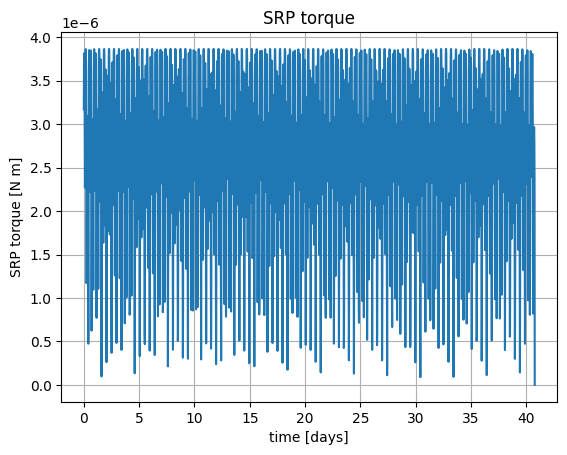

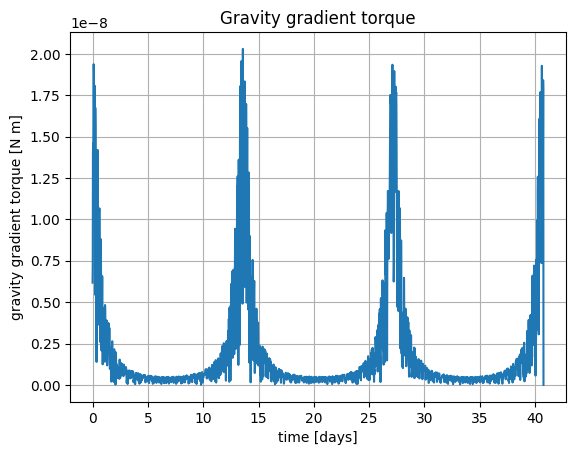

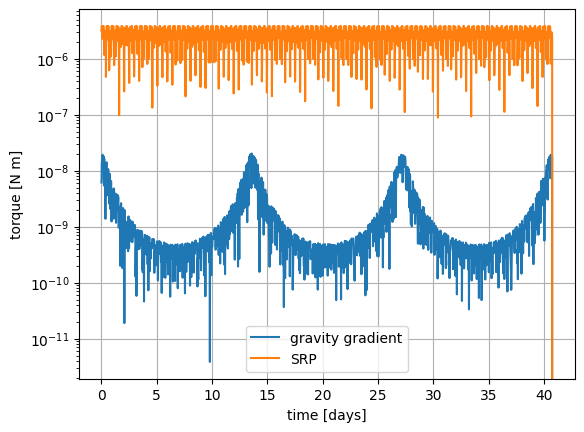

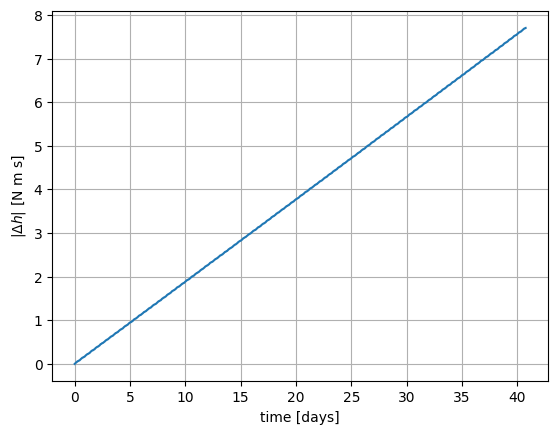

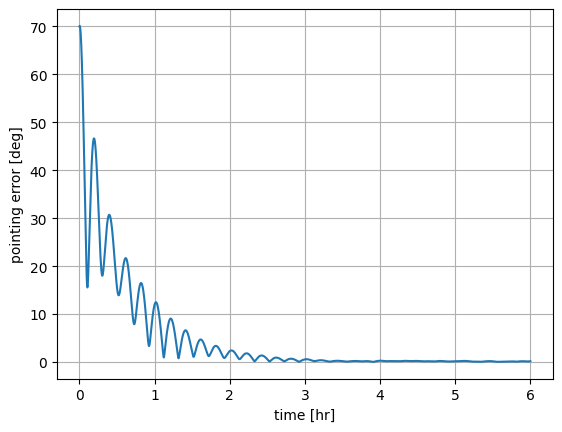

In [39]:
time_days_p2 = np.linspace(0, num_orbits*T_orbit, tau_gg_hist.shape[1]) / 86400
time_hours_p3 = t_eval / 3600

#Problem 2 Plots
plt.figure()
plt.plot(time_days_p2, tau_srp_mag)
plt.xlabel("time [days]")
plt.ylabel("SRP torque [N m]")
plt.title("SRP torque")
plt.grid(True)

plt.figure()
plt.plot(time_days_p2, tau_gg_mag)
plt.xlabel("time [days]")
plt.ylabel("gravity gradient torque [N m]")
plt.title("Gravity gradient torque")
plt.grid(True)

plt.figure()
plt.semilogy(time_days_p2, tau_gg_mag, label="gravity gradient")
plt.semilogy(time_days_p2, tau_srp_mag, label="SRP")
# plt.semilogy(time_days_p2, tau_both_mag, label="combined")
plt.xlabel("time [days]")
plt.ylabel("torque [N m]")
plt.legend()
plt.grid(True)
plt.savefig('torques.jpg')

plt.figure()
plt.plot(time_days_p2, h_accum_mag)
plt.xlabel("time [days]")
plt.ylabel(r"$|\Delta h|$ [N m s]")
plt.grid(True)
plt.savefig('momentum_accumulation.jpg')


#Problem 3 Plots
plt.figure()
plt.plot(time_hours_p3, err_deg_hist)
plt.xlabel("time [hr]")
plt.ylabel("pointing error [deg]")
plt.grid(True)
plt.savefig('pointingerror.jpg')

# plt.figure()
# plt.plot(time_hours_p3, est_err_deg_hist)
# plt.xlabel("time [hr]")
# plt.ylabel("MEKF attitude error [deg]")
# plt.grid(True)